# NOTEBOOK NAME
Created by: Thomas Durand-Texte, 2023

# Import des packages et données
## import des packages

In [6]:
import os
import time

import pandas as pd
import numpy as np
pd.set_option("display.max_columns", 200)

import pickle

from sklearn import model_selection, preprocessing

import importlib
import html_tools
import funcs

## Chargement des données

In [7]:
path_results = 'data/results/'
path_models = 'data/models/'

path_save = 'data/cleaned/'
df = pd.read_pickle(path_save + 'data.pickle')

In [8]:
with open(path_save + 'dico_tags', 'rb') as file:
    tags = pickle.load(file)

# Essais

In [9]:
df.columns

Index(['Title_clean', 'Title_processed', 'Body_clean', 'Body_processed',
       'Tags'],
      dtype='object')

In [12]:
tmp = tags['most used'].index.tolist()[0]
y_tag = funcs.compute_y_tag(df['Tags'], tmp).astype(int)

df_tags = funcs.multi_label_binarize(df['Tags'],
                                     tags['most used'].index.tolist())
display(df_tags)

x_train, x_test, y_train, y_test = model_selection.train_test_split(
                                                    df[['Title_clean',
                                                        'Body_clean',
                                                        'Title_processed',
                                                        'Body_processed'
                                                        ]],
                                                    df_tags, test_size=0.5,
                                                    random_state=7)
print('train:')
print('x:', x_train.shape)
print('y:', y_train.shape)
print('\ntest:')
print('x:', x_test.shape)
print('y:', y_test.shape)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
173250,0,1,0,0,0,0,0,0,0,0
173251,0,1,0,0,0,0,0,0,0,0
173252,0,0,0,0,1,0,0,0,0,0
173253,0,1,0,0,0,0,0,0,0,0


train:
x: (86627, 4)
y: (86627, 10)

test:
x: (86628, 4)
y: (86628, 10)


In [17]:
features = ['Title_processed', 'Body_processed']
model = 'LogisticRegression'

In [59]:
vectorised = funcs.Vectorised()
vectorised.initialize_data('tfidf',
                           funcs.concat_str_features(x_train, features),
                           y_train,
                           min_df=100, max_df=0.95, max_features=1000
                           )
vectorised.set('test', funcs.concat_str_features(x_test, features))
prediction_tags = vectorised.get_prediction_tags()

vocaublary length: 1000


## Méthode non supervisée

In [ ]:
tmp = funcs.Vectorised()
tmp.initialize_data('countvectorizer',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    min_df=100, max_df=0.95, max_features=1000
                    )
# vectorised.set('test', funcs.concat_str_features(x_test, features))

x: (86627, 1000)
vocabulary: 1000

x sum axis=0: (1000,)
most used terms (decreasing order)
['class' 'new' 'return' 'code' 'public' 'using' 'file' 'android' 'error'
 'string' 'function' 'int' 'get' 'application' 'like' 'value' 'use' '124'
 'name' 'would' 'type' 'data' 'work' 'object' 'method' 'void' 'import'
 'var' 'way' 'one' 'std' 'want' 'id' 'true' 'line' 'time' 'problem' 'null'
 'set' 'following' 'need' 'user' 'cannot' 'result' 'array' 'private'
 'test' 'example' 'run' 'know' 'also' 'version' 'call' 'tried' 'could'
 'static' 'question' 'false' '10' 'make' 'trying' 'python' 'list'
 'project' 'exception' 'something' 'const' 'see' 'java' 'div' 'find'
 'case' 'main' 'image' 'first' 'view' 'try' 'text' 'else' 'message'
 'number' 'found' 'server' 'create' 'however' 'add' 'change' 'update'
 'key' 'request' 'print' 'thread' 'script' 'item' 'used' 'two' 'issue'
 'edit' 'working' 'output' 'let' '00' 'solution' 'element' 'input' 'page'
 'override' 'url' 'different' 'possible' 'without' 'libra

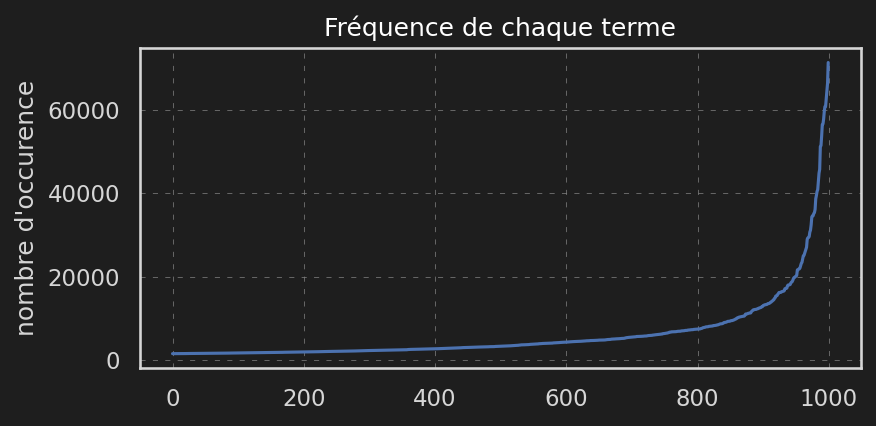

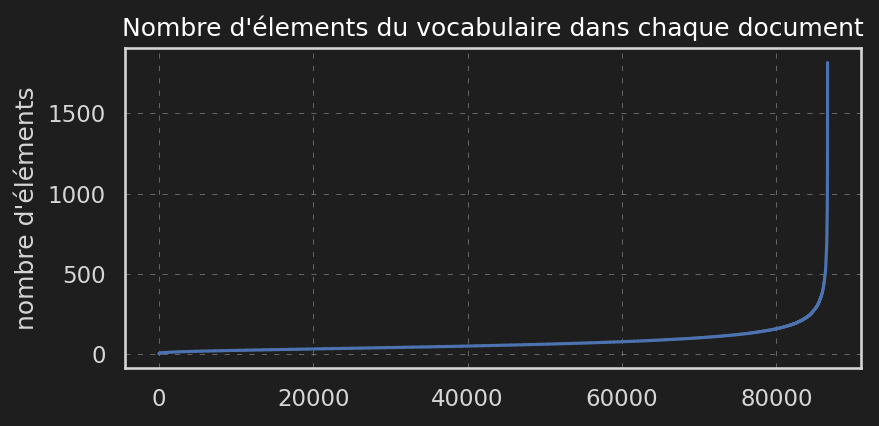

In [64]:
importlib.reload(funcs)
funcs.plot_sum_vectorizer(funcs.concat_str_features(x_train, features),
                          tmp)

In [31]:
importlib.reload(funcs)
vis = funcs.init_lda(vectorised, len(tags['most used']))

LDA: 10 topics
iteration: 1 of max_iter: 10
iteration: 2 of max_iter: 10
iteration: 3 of max_iter: 10
iteration: 4 of max_iter: 10
iteration: 5 of max_iter: 10
iteration: 6 of max_iter: 10
iteration: 7 of max_iter: 10
iteration: 8 of max_iter: 10
iteration: 9 of max_iter: 10
iteration: 10 of max_iter: 10


In [32]:
funcs.show_lda_vis(vis)

Les résultats ne semblent pas exploitable. Le terme "python" apparaît, lié aux topics 1,2,5 et 9, (3,4 et 10 partiellement).
L'utilisation pour prédire les tags semblent inappropriée.

## PCA

In [15]:
vectorised.pca_fit_on_train(1000)

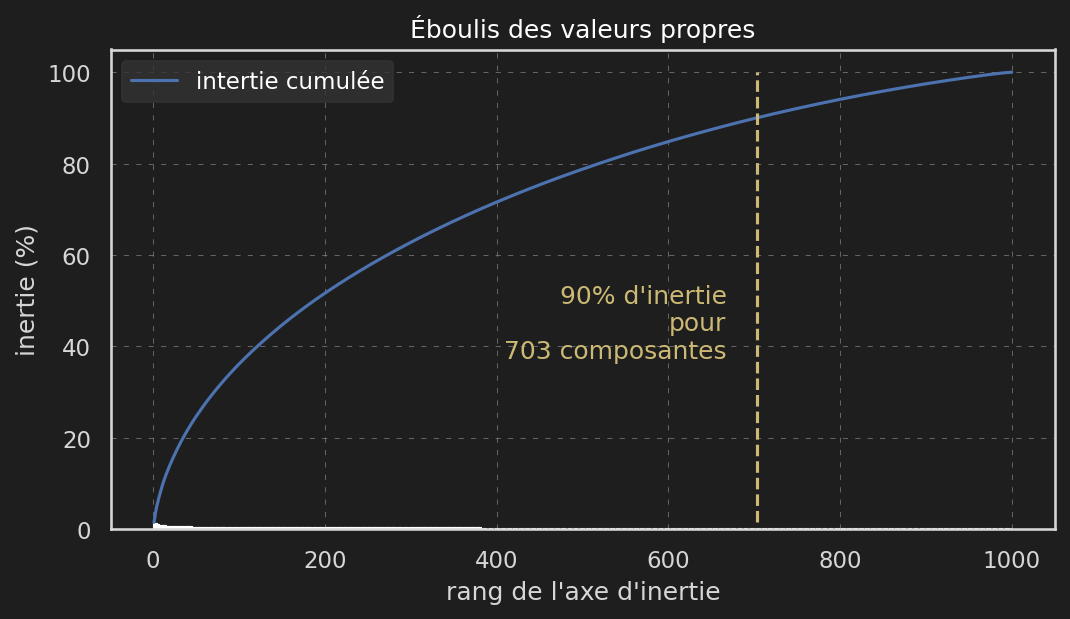

In [16]:
funcs.plot_ebouli_pca(vectorised.pca, 90, 'ebouli_tfidf')

In [60]:
vectorised.train_classifier(model, b_scale_x=True, n_pca_components=0)
y_pred = vectorised.predict('train')
y_true = y_train.values

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res.style.format(precision=2).set_caption('without PCA'))

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.34,97.11,90.58,96.12,92.94,85.95,91.94,89.95,94.83,91.65
recall,81.45,89.91,72.16,87.48,83.54,71.41,77.40,77.51,80.63,73.04
specificity,98.35,99.55,98.59,99.53,98.90,97.97,99.85,99.38,99.67,99.80
F1 score,85.66,93.37,80.33,91.60,87.99,78.01,84.04,83.26,87.15,81.30


In [61]:
vectorised.train_classifier(model, b_scale_x=True, n_pca_components=700)
y_pred = vectorised.predict('train')
prediction_tags = vectorised.get_prediction_tags()
y_true = y_train.values

df_res_pca = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res.style.format(precision=2).set_caption('with PCA'))

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.34,97.11,90.58,96.12,92.94,85.95,91.94,89.95,94.83,91.65
recall,81.45,89.91,72.16,87.48,83.54,71.41,77.40,77.51,80.63,73.04
specificity,98.35,99.55,98.59,99.53,98.90,97.97,99.85,99.38,99.67,99.80
F1 score,85.66,93.37,80.33,91.60,87.99,78.01,84.04,83.26,87.15,81.30


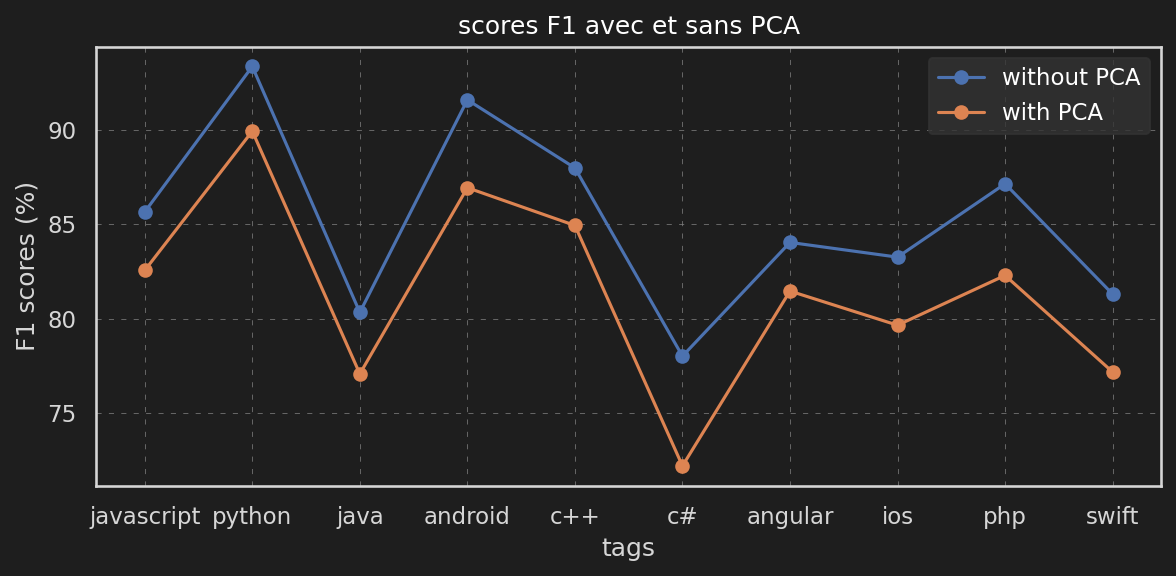

In [62]:
results = {'without PCA': df_res.iloc[-1],
           'with PCA': df_res_pca.iloc[-1]}

funcs.plot_f1_scores(results, prediction_tags, 'avec et sans PCA', 'PCA')

La PCA n'apporte pas d'améliorations particulière.

## Convergence des classifieurs

In [33]:
vectorised = funcs.Vectorised()
vectorised.initialize_data('tfidf',
                           funcs.concat_str_features(x_train, features),
                           y_train,
                           min_df=100, max_df=0.95, max_features=300
                           )
vectorised.set('test', funcs.concat_str_features(x_test, features))

vocaublary length: 300


In [40]:
results = {}
def test_model(vectorised, model, b_scale_x):
    tmp = funcs.Vectorised()
    tmp.copy_data_from_vetorizer(vectorised)

    t0 = time.time()
    tmp.train_classifier(model, b_scale_x=b_scale_x)
    print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

    y_pred = tmp.predict('test')
    y_true = y_test.values
    prediction_tags = tmp.get_prediction_tags()

    df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
    # display(df_res)
    display(df_res.style.format(precision=2).set_caption(model))
    results[model] = df_res.iloc[-1, :]

In [36]:
vectorised.x['train']

<86627x300 sparse matrix of type '<class 'numpy.float64'>'
	with 2169507 stored elements in Compressed Sparse Row format>

In [41]:
test_model(vectorised, 'Dummy', b_scale_x=False)

elapsed time: 0.42 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
recall,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
specificity,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
F1 score,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [11]:
# ne converge pas
# test_model(vectorised, 'svc')

In [42]:
test_model(vectorised, 'Logistic Regression', b_scale_x=False)

elapsed time: 16.23 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,87.45,95.05,87.71,96.16,89.61,75.29,76.69,87.47,94.68,82.18
recall,69.31,79.51,58.91,77.04,71.76,45.58,24.99,55.18,62.75,30.53
specificity,98.07,99.31,98.47,99.59,98.58,97.41,99.82,99.43,99.74,99.80
F1 score,77.33,86.59,70.48,85.54,79.70,56.78,37.69,67.67,75.48,44.52


In [43]:
test_model(vectorised, 'Logistic Regression', b_scale_x=True)

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


elapsed time: 47.71 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,87.07,94.41,87.03,95.53,88.54,73.68,76.37,86.09,93.37,81.18
recall,71.30,81.72,60.77,79.32,73.63,48.85,30.03,59.22,66.36,35.28
specificity,97.94,99.19,98.32,99.50,98.38,96.98,99.78,99.31,99.66,99.75
F1 score,78.40,87.61,71.56,86.67,80.40,58.75,43.11,70.17,77.58,49.19


In [44]:
test_model(vectorised, 'SDG Classifier', b_scale_x=True)

elapsed time: 32.65 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.62,93.45,85.89,93.59,86.02,66.54,53.26,86.20,91.49,79.00
recall,69.89,80.22,57.01,79.90,72.81,47.65,36.78,56.55,66.41,35.59
specificity,97.53,99.06,98.26,99.27,97.98,95.85,99.24,99.35,99.55,99.71
F1 score,76.55,86.33,68.53,86.21,78.87,55.53,43.51,68.30,76.96,49.07


In [45]:
test_model(vectorised, 'Multinomial NB', b_scale_x=False)

elapsed time: 0.85 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.06,98.76,90.86,98.71,95.15,94.89,84.21,95.79,98.18,100.00
recall,41.30,49.43,22.48,48.56,55.45,2.61,0.80,15.60,21.18,0.43
specificity,99.11,99.90,99.58,99.91,99.52,99.98,100.00,99.95,99.97,100.00
F1 score,56.63,65.88,36.05,65.10,70.07,5.09,1.58,26.84,34.84,0.85


In [46]:
test_model(vectorised, 'Perceptron', b_scale_x=True)

elapsed time: 2.36 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,69.96,84.85,62.71,78.00,74.68,49.59,35.60,57.98,62.91,42.49
recall,68.42,78.86,64.05,80.39,72.65,49.26,33.73,59.69,69.12,34.70
specificity,94.29,97.66,92.92,96.96,95.80,91.33,98.56,96.88,97.04,98.57
F1 score,69.18,81.74,63.37,79.18,73.65,49.43,34.64,58.82,65.87,38.20


In [47]:
test_model(vectorised, 'Passive Aggressive Classifier', b_scale_x=True)

elapsed time: 3.50 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,72.38,78.13,64.09,77.56,71.88,46.37,38.20,63.30,61.42,36.92
recall,67.73,79.21,56.20,66.81,71.28,49.62,33.58,55.95,64.03,40.62
specificity,94.98,96.31,94.15,97.41,95.25,90.06,98.72,97.66,97.08,97.88
F1 score,69.98,78.66,59.89,71.79,71.58,47.94,35.74,59.40,62.70,38.68


Text(0.5, 1.0, 'scores F1 pour différents modèles')

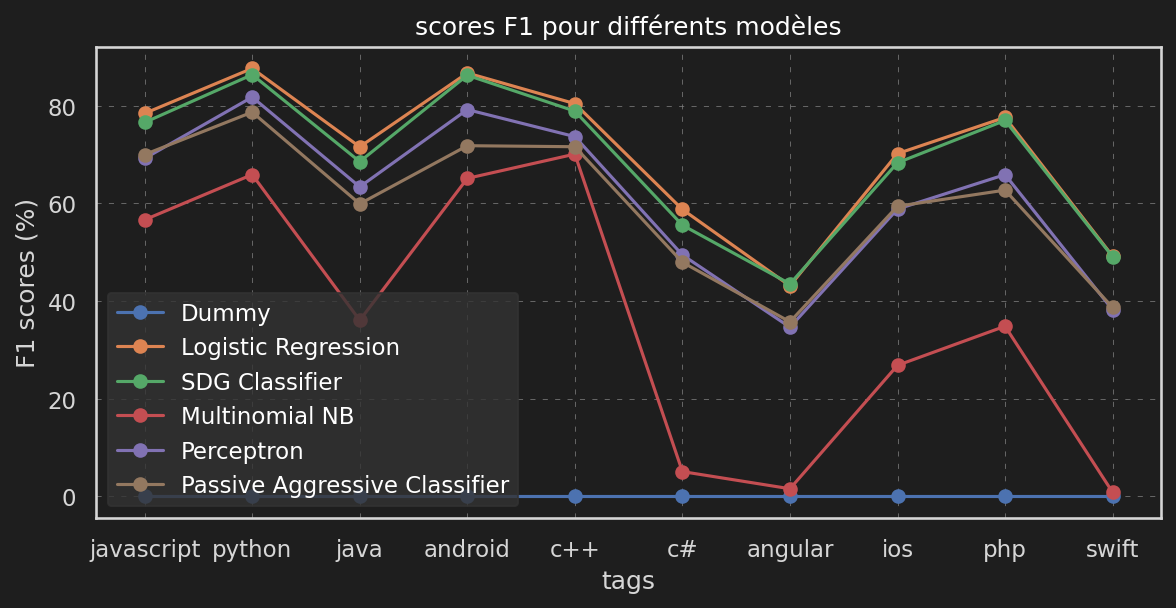

In [49]:
importlib.reload(funcs)
ax = funcs.plot_f1_scores(results, prediction_tags)
ax.set_title('scores F1 pour différents modèles')

### Remarques:
SDG Classfier et Logistic regressions donnent de meilleurs résultats, mais le temps de calcul est plus long.

In [50]:
model = 'Logistic Regression'

## Optimisation des decision thresholds

In [56]:
tmp = funcs.Vectorised()
tmp.copy_data_from_vetorizer(vectorised)

t0 = time.time()
tmp.train_classifier(model)

y_pred = tmp.predict('test')
y_true = y_test.values

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res.style.format(precision=2).set_caption('threshold "basique"'))

results = {'seuil basique': df_res.iloc[-1]}

tmp.optimize_threshold()
y_pred = tmp.predict_optim_threshold('test')
df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res.style.format(precision=2).set_caption('threshold "optimisé"'))
results['seuil optimisé par tag'] = df_res.iloc[-1]

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,87.07,94.41,87.03,95.53,88.55,73.68,76.37,86.09,93.37,81.18
recall,71.30,81.72,60.77,79.32,73.63,48.87,30.03,59.22,66.36,35.28
specificity,97.94,99.19,98.32,99.50,98.38,96.98,99.78,99.31,99.66,99.75
F1 score,78.40,87.61,71.56,86.67,80.41,58.76,43.11,70.17,77.58,49.19


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,81.65,89.87,78.39,91.96,83.08,61.01,54.96,76.35,89.02,68.63
recall,77.63,85.44,68.41,82.46,78.42,66.09,45.13,68.93,70.38,44.90
specificity,96.61,98.40,96.50,99.03,97.28,92.69,99.13,98.46,99.37,99.37
F1 score,79.59,87.60,73.06,86.95,80.68,63.45,49.56,72.45,78.61,54.28


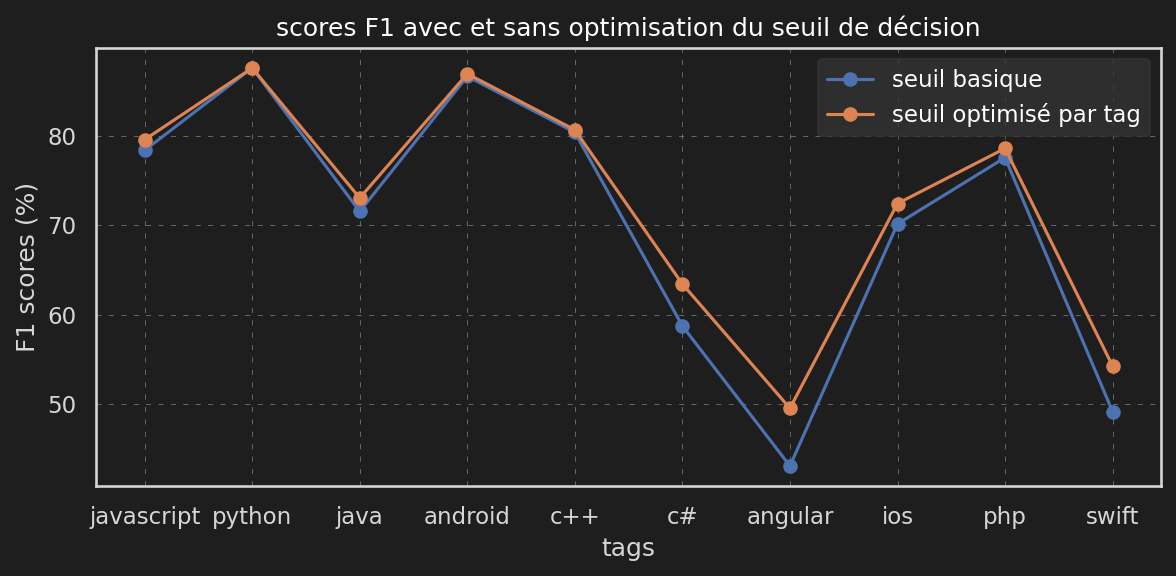

In [58]:
importlib.reload(funcs)
funcs.plot_f1_scores(results,
                     prediction_tags,
                     'avec et sans optimisation du seuil de décision',
                     'decision_threshold')

Les résultats sont améliorés en optimisant le seuil de décision par tag.

## Longueur du vocabulaire

In [21]:
results = {}
for max_features in [300, 600, 900, 1200]:
    tmp = funcs.Vectorised()
    tmp.initialize_data('tfidf',
                           funcs.concat_str_features(x_train, features),
                           y_train,
                           min_df=100, max_df=0.95, max_features=max_features
                           )
    tmp.set('test', funcs.concat_str_features(x_test, features))
    t0 = time.time()
    tmp.train_classifier(model)
    tmp.optimize_threshold()
    print(f'max fatures : {max_features}, elapsed time: {time.time()-t0:.2f} sec.')

    y_pred = tmp.predict_optim_threshold('test')
    y_true = y_test.values
    prediction_tags = tmp.get_prediction_tags()
    df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
    n_features = len(tmp.get_vocabulary())
    results[n_features] = df_res.iloc[-1,:]

vocaublary length: 300


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max fatures : 300, elapsed time: 57.72 sec.
vocaublary length: 600


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

max fatures : 600, elapsed time: 147.11 sec.
vocaublary length: 900


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

max fatures : 900, elapsed time: 209.70 sec.
vocaublary length: 1200


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

max fatures : 1200, elapsed time: 275.52 sec.


In [22]:
filename = 'data/results/vobaculary_length'
if False:
    with open(filename, 'wb') as file:
        pickle.dump(results, file)
else:
    with open(filename, 'rb') as file:
        results = pickle.load(file)
del filename

Text(0.5, 1.0, 'F1 score pour différentes longueurs de vocabulaire')

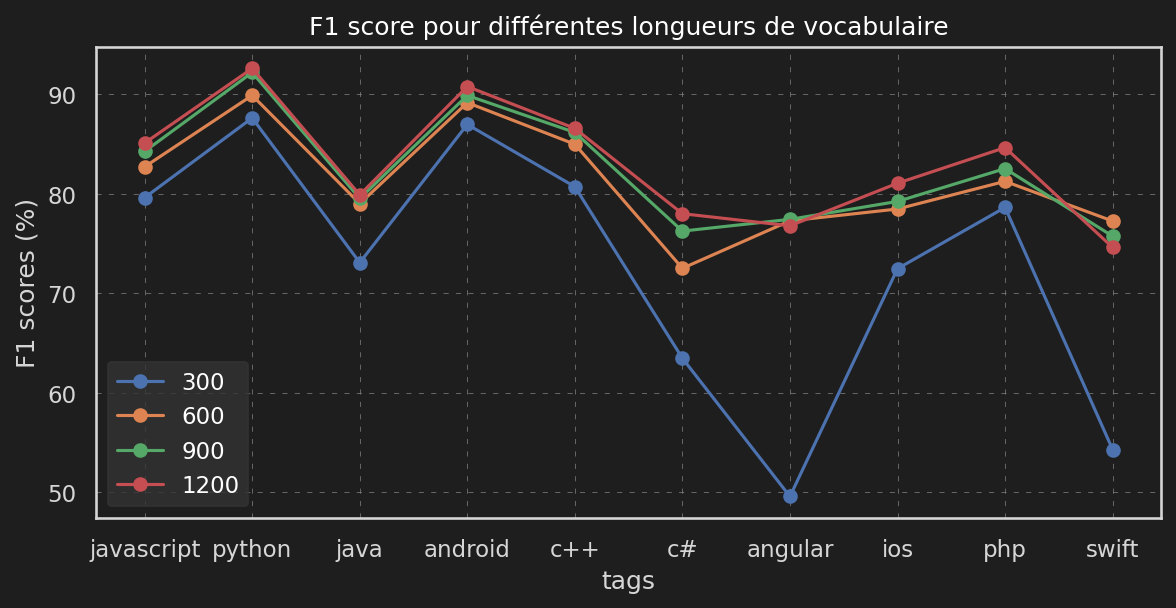

In [23]:
importlib.reload(funcs)
ax = funcs.plot_f1_scores(results, prediction_tags)
ax.set_title('F1 score pour différentes longueurs de vocabulaire')

In [8]:
importlib.reload(funcs)
vectorised = funcs.Vectorised()
vectorised.initialize_data('tfidf',
                        funcs.concat_str_features(x_train, features),
                        y_train,
                        min_df=100, max_df=0.95, max_features=900
                        )
vectorised.set('test', funcs.concat_str_features(x_test, features))

vocaublary length: 900


## Optimisation des hyper paramètres

In [29]:
importlib.reload(funcs)
results = {}
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    tmp = funcs.Vectorised()
    tmp.copy_data_from_vetorizer(vectorised)
    t0 = time.time()
    tmp.train_classifier(model, kernel_params={'C':C})
    tmp.optimize_threshold()
    print('C: {:}, elapsed time: {:.2f} seconds'.format(C, time.time()-t0))

    y_pred = tmp.predict_optim_threshold('test')
    y_true = y_test.values
    prediction_tags = tmp.get_prediction_tags()

    df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
    display(df_res)
    results[C] = df_res.iloc[-1, :]

C: 0.01, elapsed time: 79.07 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.34,93.90,82.99,92.47,87.78,77.05,83.48,78.37,87.31,77.30
recall,83.52,90.14,76.13,85.99,84.04,74.71,74.51,79.82,78.02,74.38
specificity,96.99,99.03,97.10,99.06,98.01,96.15,99.65,98.41,99.18,99.33
F1 score,83.93,91.98,79.41,89.12,85.87,75.86,78.74,79.09,82.41,75.81


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

C: 0.1, elapsed time: 209.68 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.64,94.57,83.60,92.30,88.90,77.10,81.12,80.09,87.31,79.20
recall,83.81,89.94,75.78,87.26,83.52,75.27,75.56,78.24,78.33,72.66
specificity,97.04,99.14,97.24,99.02,98.22,96.13,99.58,98.60,99.17,99.42
F1 score,84.22,92.20,79.50,89.71,86.13,76.18,78.24,79.16,82.57,75.79


...

C: 100, elapsed time: 215.48 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.60,94.10,83.48,93.23,88.42,76.30,80.17,78.83,86.11,78.40
recall,83.89,90.23,75.90,86.78,83.95,76.20,75.76,79.54,78.92,73.09
specificity,97.03,99.06,97.21,99.16,98.13,95.90,99.56,98.46,99.07,99.38
F1 score,84.24,92.13,79.51,89.89,86.13,76.25,77.90,79.18,82.36,75.65


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

C: 1000, elapsed time: 223.08 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.60,94.38,83.48,93.23,88.42,76.29,80.19,78.83,86.10,78.38
recall,83.89,90.07,75.90,86.78,83.95,76.20,75.86,79.54,78.91,73.13
specificity,97.03,99.11,97.21,99.16,98.13,95.90,99.56,98.46,99.07,99.38
F1 score,84.24,92.17,79.51,89.89,86.13,76.25,77.97,79.18,82.35,75.66


In [ ]:
filename = 'regularisation'
if False:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(results, file)
else:
    with open(path_results + filename, 'rb') as file:
        results = pickle.load(file)
del filename

Text(0.5, 1.0, 'F1 score pour différentes pénalités (l2)')

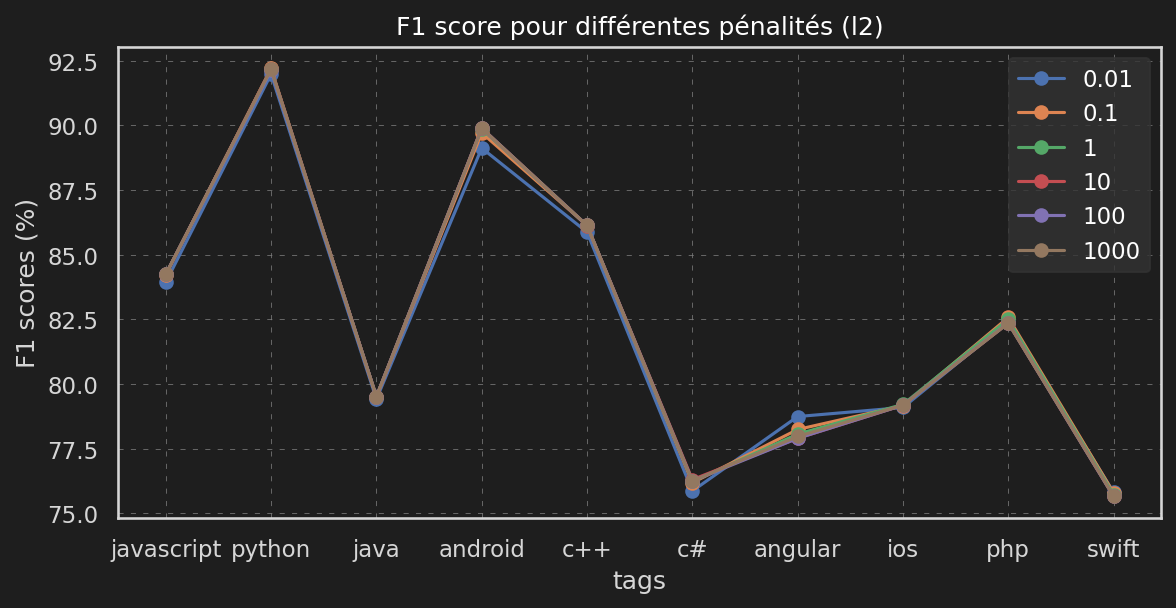

In [30]:
ax = funcs.plot_f1_scores(results, prediction_tags)
ax.set_title('F1 score pour différentes pénalités (l2)')

## Extra Trees

<span style="color:red"> voir randomizeGridSearchCV </span> ?

Temps de calcul pour une forêt : 33 minutes pour 1 configuration.
* pour ce projet, on s'en passera
* dans un cadre industriel, passer sur un calculateur, en fonction des possibilités du client

In [9]:
param_grid = {
              'max_depth': [None],#, 5, 10],
              'max_features':['sqrt', 'log2', None],
              'min_samples_split': [2], #, 4],
              'min_samples_leaf': [1], #, 4],
}

importlib.reload(funcs)
trees = funcs.train_extra_trees(vectorised, param_grid)

x_train: (86627, 900)
y_train: (86627, 10)
x_train: (86627, 900)
y_train: (86627, 10)
best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
if True:
    with open('data/models/trees.pickle', 'wb') as file:
        pickle.dump(trees, file)
else:
    with open('data/models/trees.pickle', 'rb') as file:
        trees = pickle.load(file)

In [11]:
y_pred = trees.predict(vectorised.scale(vectorised.get('test')))
y_true = y_test.values
prediction_tags = vectorised.get_prediction_tags()

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,93.78,98.62,97.14,98.79,97.18,95.83,96.32,90.06,97.98,93.90
recall,69.86,81.57,57.64,70.77,69.29,39.70,28.79,51.27,55.38,44.39
specificity,99.10,99.81,99.69,99.88,99.66,99.70,99.97,99.59,99.92,99.91
F1 score,80.07,89.29,72.35,82.46,80.90,56.15,44.32,65.34,70.76,60.29


In [12]:
filename = 'data/results/trees.pickle'
with open(filename, 'wb') as file:
    pickle.dump(df_res, file)

In [158]:
def grid_search_cv_model(vectorised, model, param_grid):
    tmp = funcs.Vectorised()
    tmp.copy_data_from_vetorizer(vectorised)

    t0 = time.time()
    tmp.grid_search_cv(model, param_grid)
    print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

    y_pred = tmp.predict('test')
    y_true = y_test.values
    prediction_tags = tmp.get_prediction_tags()

    df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
    display(df_res)

## méthodes "Deep Learning"

### Word2Vect

La méthode est limitée par le fait qu'elle prend en compte chaque mot séparément.

In [13]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('word2vec',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

In [14]:
importlib.reload(funcs)
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

elapsed time: 103.38 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,71.35,77.26,65.29,78.04,80.55,56.54,64.18,64.58,68.02,61.71
recall,70.77,75.27,65.08,72.80,76.80,61.92,58.37,63.73,61.81,57.48
specificity,94.48,96.31,93.57,97.26,96.84,91.76,99.23,97.48,97.89,98.91
F1 score,71.06,76.26,65.19,75.32,78.63,59.11,61.14,64.15,64.77,59.52


In [15]:
filename = 'data/results/w2v.pickle'
with open(filename, 'wb') as file:
    pickle.dump(df_res, file)

### SBERT

In [17]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('sbert',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

In [18]:
importlib.reload(funcs)
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values
prediction_tags = tmp.get_prediction_tags()

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

elapsed time: 105.53 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,89.16,97.23,88.01,94.43,93.64,88.11,87.86,85.10,92.82,80.66
recall,88.94,93.57,81.13,91.45,89.71,82.59,85.76,89.78,88.01,70.99
specificity,97.90,99.56,97.95,99.28,98.96,98.07,99.72,98.87,99.50,99.48
F1 score,89.05,95.37,84.43,92.91,91.63,85.26,86.80,87.38,90.35,75.52


In [20]:
filename = 'SBERT.pickle'

if True:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(df_res, file)

    with open(path_models + filename, 'wb') as file:
        pickle.dump(tmp.__dict__, file)
else:
    with open(path_models + filename, 'rb') as file:
        dict_tmp = pickle.load(file)
        tmp = funcs.Vectorised()
        tmp.copy_data_from_dict(dict_tmp)

# filename = 'SBERT_x.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.get('train'), tmp.get('test')), file)
# filename = 'data/models/SBERT_y.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.y_train, y_test), file)

In [7]:
importlib.reload(funcs)

# filename = 'data/results/SBERT.pickle'
# with open(filename, 'rb') as file:
#     df_res_tmp = pickle.load(file)

# display(df_res_tmp)

# y_pred = tmp.predict_optim_threshold('test')
# df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
# display(df_res)

<module 'funcs' from '/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/funcs.py'>

In [8]:
features = ['Title_clean', 'Body_clean']

In [9]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('sbert',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

SBERT vectorization:
100.00%    

SBERT vectorization:
100.00%    



In [10]:
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

elapsed time: 103.46 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.27,97.48,88.90,94.63,94.36,91.54,89.61,86.92,94.60,81.51
recall,90.72,96.16,82.59,92.36,92.82,86.29,87.51,88.55,92.13,76.91
specificity,98.10,99.59,98.08,99.30,99.05,98.62,99.76,99.04,99.62,99.47
F1 score,90.49,96.82,85.62,93.48,93.58,88.84,88.55,87.73,93.35,79.14


In [17]:
filename = 'SBERT_on_clean.pickle'

if False:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(df_res, file)

    with open(path_models + filename, 'wb') as file:
        pickle.dump(tmp.__dict__, file)
else:
    with open(path_models + filename, 'rb') as file:
        dict_tmp = pickle.load(file)
        tmp2 = funcs.Vectorised()
        tmp2.copy_data_from_dict(dict_tmp)
        
        y_pred = tmp2.predict_optim_threshold('test')
        y_true = y_test.values
        prediction_tags = tmp2.get_prediction_tags()

        df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
        display(df_res)

# filename = 'SBERT_x.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.get('train'), tmp.get('test')), file)
# filename = 'data/models/SBERT_y.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.y_train, y_test), file)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.27,97.48,88.90,94.63,94.36,91.54,89.61,86.92,94.60,81.51
recall,90.72,96.16,82.59,92.36,92.82,86.29,87.51,88.55,92.13,76.91
specificity,98.10,99.59,98.08,99.30,99.05,98.62,99.76,99.04,99.62,99.47
F1 score,90.49,96.82,85.62,93.48,93.58,88.84,88.55,87.73,93.35,79.14


### Universal Sentence Encoder

In [19]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('use',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

2023-05-08 17:22:09.686432: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype string
	 [[{{node inputs}}]]


USE vectorization:
100.00%    

USE vectorization:
100.00%    



In [20]:
importlib.reload(funcs)
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


elapsed time: 97.06 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,86.60,94.56,89.21,93.53,91.81,88.10,80.67,87.34,92.40,73.35
recall,86.07,91.77,79.81,89.71,89.23,84.44,78.41,84.79,87.79,71.69
specificity,97.41,99.12,98.21,99.17,98.64,98.03,99.56,99.11,99.47,99.20
F1 score,86.33,93.14,84.25,91.58,90.50,86.23,79.52,86.04,90.04,72.51


In [23]:
filename = 'USE.pickle'

if True:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(df_res, file)

    with open(path_models + filename, 'wb') as file:
        tmp_dict = tmp.__dict__
        tmp_dict.pop('vectorizer')
        pickle.dump(tmp_dict, file)
else:
    with open(path_models + filename, 'rb') as file:
        dict_tmp = pickle.load(file)
        tmp = funcs.Vectorised()
        tmp.copy_data_from_dict(dict_tmp)
        # ! AJOUT VECTORIZER

### Conclusions

Text(0.5, 1.0, 'F1 score pour différentes véctorisations')

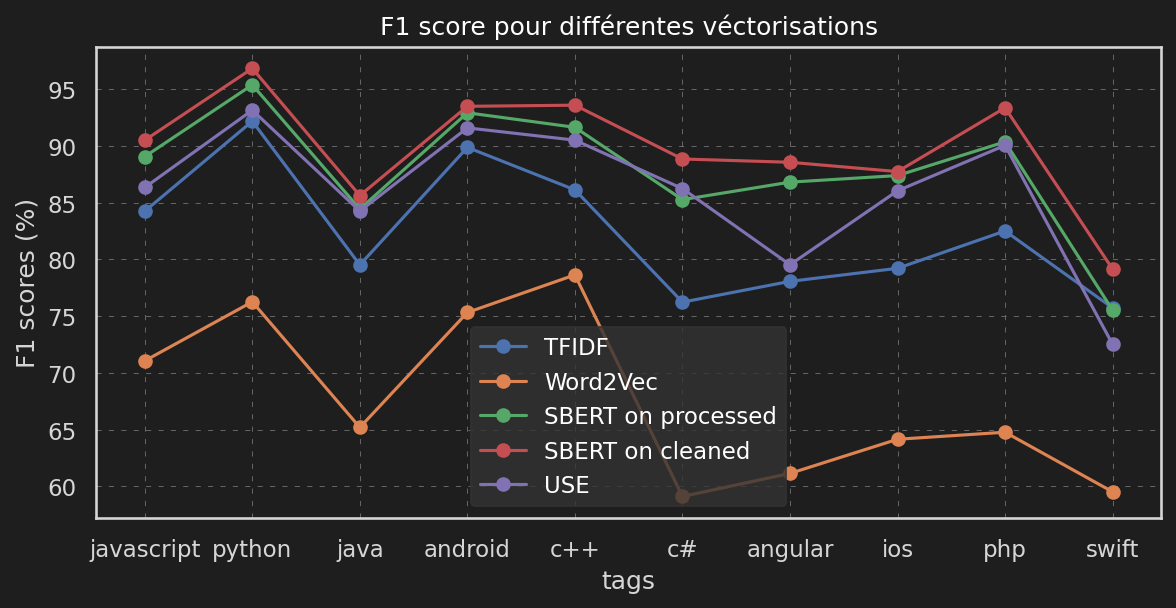

In [16]:
df_res = {}
with open(path_results + 'regularisation', 'rb') as file:
    df_res['TFIDF'] = pickle.load(file)[1]

with open(path_results + 'w2v.pickle', 'rb') as file:
    df_res['Word2Vec'] = pickle.load(file).iloc[-1,:]

with open(path_results + 'SBERT.pickle', 'rb') as file:
    df_res['SBERT on processed'] = pickle.load(file).iloc[-1,:]

with open(path_results + 'SBERT_on_clean.pickle', 'rb') as file:
    df_res['SBERT on cleaned'] = pickle.load(file).iloc[-1,:]

with open(path_results + 'USE.pickle', 'rb') as file:
    df_res['USE'] = pickle.load(file).iloc[-1,:]

ax = funcs.plot_f1_scores(df_res, vectorised.get_prediction_tags())
ax.set_title('F1 score pour différentes véctorisations')

---